In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re, pathlib

path = pathlib.Path('../dump_compare/compare_signal.txt')
assert path.exists(), f'Run ./build/compare_demo first — {path} not found'

meta = {}
for line in path.read_text().splitlines():
    if not line.startswith('#'): break
    for k, v in re.findall(r'(\w+)=([\d.e+\-]+)', line):
        meta[k] = float(v)

data = np.loadtxt(path, comments='#')
col, R_fft, R_cnn, diff = data[:,0], data[:,1], data[:,2], data[:,3]

W          = int(meta['W'])
sigma      = meta['sigma']
erosion    = int(meta['erosion'])
B          = int(meta['B'])
fft_ms     = meta['fft_ms']
cnn_ms     = meta['cnn_ms']
fft_ws_gb  = meta['fft_ws_bytes'] / 2**30
cnn_ws_gb  = meta['cnn_ws_bytes'] / 2**30

print(f'sigma={sigma}  erosion={erosion}  W={W}  B={B}')
print(f'FFT:         {fft_ms:.2f} ms,  {fft_ws_gb:.2f} GB')
print(f'Strip cuDNN: {cnn_ms:.2f} ms,  {cnn_ws_gb:.2f} GB')
print(f'Max |diff|={np.abs(diff).max():.3e}   RMS diff={np.sqrt((diff**2).mean()):.3e}')

sigma=20.0  erosion=60  W=136  B=3000
FFT:         55.39 ms,  6.63 GB
Strip cuDNN: 45.68 ms,  1.06 GB
Max |diff|=5.960e-07   RMS diff=1.356e-07


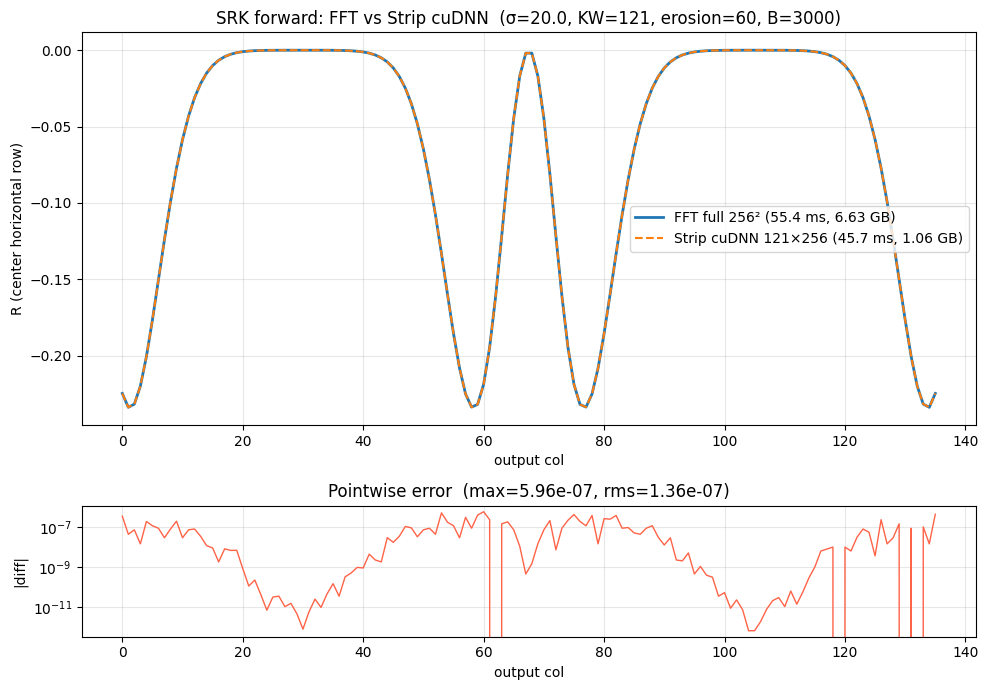

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
ax.plot(col, R_fft, label=f'FFT full 256² ({fft_ms:.1f} ms, {fft_ws_gb:.2f} GB)', lw=2)
ax.plot(col, R_cnn, '--', label=f'Strip cuDNN 121×256 ({cnn_ms:.1f} ms, {cnn_ws_gb:.2f} GB)', lw=1.5)
ax.set_xlabel('output col')
ax.set_ylabel('R (center horizontal row)')
ax.set_title(f'SRK forward: FFT vs Strip cuDNN  (σ={sigma}, KW={int(meta["KW"])}, erosion={erosion}, B={B})')
ax.legend()
ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.semilogy(col, np.abs(diff), color='tomato', lw=1)
ax2.set_xlabel('output col')
ax2.set_ylabel('|diff|')
ax2.set_title(f'Pointwise error  (max={np.abs(diff).max():.2e}, rms={np.sqrt((diff**2).mean()):.2e})')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../dump_compare/compare_signal.png', dpi=150)
plt.show()

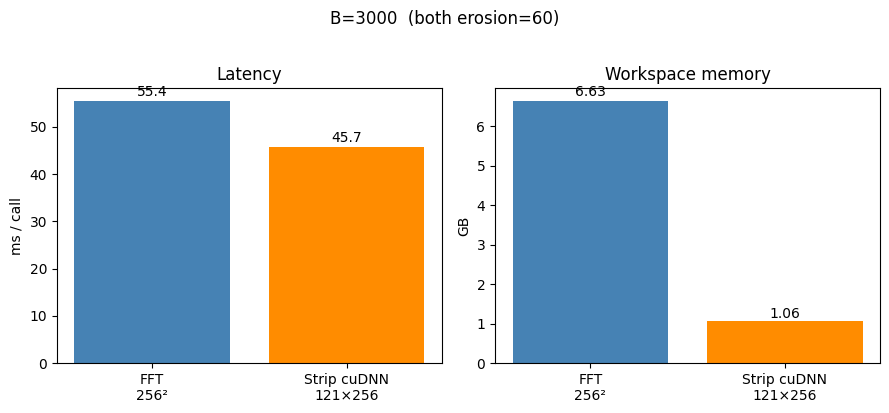

In [3]:
# Performance bar chart
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

labels = ['FFT\n256²', 'Strip cuDNN\n121×256']
colors = ['steelblue', 'darkorange']

axes[0].bar(labels, [fft_ms, cnn_ms], color=colors)
axes[0].set_ylabel('ms / call')
axes[0].set_title('Latency')
for i, v in enumerate([fft_ms, cnn_ms]):
    axes[0].text(i, v*1.01, f'{v:.1f}', ha='center', va='bottom')

axes[1].bar(labels, [fft_ws_gb, cnn_ws_gb], color=colors)
axes[1].set_ylabel('GB')
axes[1].set_title('Workspace memory')
for i, v in enumerate([fft_ws_gb, cnn_ws_gb]):
    axes[1].text(i, v*1.01, f'{v:.2f}', ha='center', va='bottom')

plt.suptitle(f'B={B}  (both erosion={erosion})', y=1.02)
plt.tight_layout()
plt.savefig('../dump_compare/compare_perf.png', dpi=150)
plt.show()